<a href="https://colab.research.google.com/github/TalCordova/RS_Coller_TAU_26B/blob/master/notebook2_ranking_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2: Ranking & Evaluation

In Notebook 1 we built item-item and user-user CF models that produce a **predicted rating score** for any (user, item) pair. But in production, we never show users a single number — we show them a **ranked list**.

This notebook covers:
1. Turning scores into a recommendation list
2. Evaluating that list with ranking metrics: **HR@K**, **NDCG@K**, and **MRR**
3. Training a **BPR** model that optimizes for ranking directly
4. Comparing pointwise vs. pairwise approaches
5. Things to consider: cold start, popularity bias, and beyond accuracy

## Section 0: Setup

In [1]:
!pip install numpy pandas scikit-learn matplotlib seaborn implicit --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 66.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
import implicit
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 4)
sns.set_style('whitegrid')
print("✅ All packages loaded")

✅ All packages loaded


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Section 1: Load Data & Rebuild the CF Matrix


In [19]:
# ── Load from Google Drive ─────────────────────────────────────────────────

RATINGS_PATH = "/content/drive/MyDrive/PhD - TAU/RS_Course_SemB26/ratings.csv"
MOVIES_PATH  = "/content/drive/MyDrive/PhD - TAU/RS_Course_SemB26/movies.csv"

ratings = pd.read_csv(RATINGS_PATH)
movies  = pd.read_csv(MOVIES_PATH)
print(f"Ratings: {len(ratings):,} | Users: {ratings['userId'].nunique()} | Movies: {ratings['movieId'].nunique()}")

Ratings: 100,836 | Users: 610 | Movies: 9724


In [23]:
# ── Filter & split ───────────────────────────────────
MIN_INTERACTIONS = 5
active_users     = ratings.groupby('userId')['movieId'].count()
active_users     = active_users[active_users >= MIN_INTERACTIONS].index
ratings_filtered = ratings[ratings['userId'].isin(active_users)].copy()

def user_temporal_split(df, test_frac=0.2):
    """For each user, hold out their most recent interactions as test."""
    train_list, test_list = [], []
    for _, user_df in df.groupby('userId'):
        user_df = user_df.sort_values('timestamp')
        n_test  = max(1, int(len(user_df) * test_frac))
        test_list.append(user_df.iloc[-n_test:])
        train_list.append(user_df.iloc[:-n_test])
    return pd.concat(train_list), pd.concat(test_list)

train, test = user_temporal_split(ratings_filtered)

In [26]:
# ── Build utility matrix & item-item kNN ──────────────────────────────────
utility_train    = train.pivot_table(index='userId', columns='movieId', values='rating')
user_means       = utility_train.mean(axis=1)
utility_centered = utility_train.sub(user_means, axis=0)

X               = utility_centered.fillna(0).values
movie_ids_index = list(utility_centered.columns)
user_ids_index  = list(utility_centered.index)

model_item = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=21)
model_item.fit(X.T)
print(f"✅ Item-item model ready | Matrix: {X.shape[0]} users × {X.shape[1]} movies")

✅ Item-item model ready | Matrix: 610 users × 8247 movies


---
## Section 2: From Interactions to a Ranked List

We have clean interaction data and a train/test split. Now what?

There are two ways to frame the recommendation problem:

* **Predict a score** — for each (user, item) pair, predict how much the user will like the item. This could be a star rating, an interaction probability, or any other absolute measure. This is intuitive and closely resembles standard regression or classification problems.

* **Produce a ranked list** — for each user, produce an ordered list of the top K items most likely to be relevant to them. The absolute score doesn't matter — only the order does.

In practice, most production systems care about the ranked list. You are not showing users a predicted rating — you are showing them a list of recommendations.

> 💡 Rating is very similar to other classic ML regression problems, so we will focus on ranking - how to produce a good list, how to evaluate it, and how to train a model that optimizes directly for it.

### 2.1 Pairwise and Pointwise Ranking

How do we get scores? There are two fundamentally different approaches:

| | Pointwise | Pairwise |
|---|---|---|
| **Looks at** | One item at a time | Pairs of items |
| **Asks** | "What score should this item get?" | "Should item A rank above item B?" |
| **Loss** | MSE / RMSE / cross-entropy | BPR |
| **Optimizes for** | Absolute score accuracy | Relative order |

The difference is in what the loss function penalizes.

A pointwise model scores each item independently and is penalized for how wrong that score is. If the model predicts 2.1 for item A and the true label is 1, it gets penalized — even if item A was correctly ranked below everything else.

A pairwise model looks at two items at a time and only asks: did we get the order right? If item A should rank above item B and it does, there is no penalty — regardless of what the actual scores are.

Neither is the correct choice by default. It depends on what your system needs to be good at. In this notebook we implement both and compare them on the same evaluation.

> 💡 Pointwise treats ranking as a standard regression or classification problem — one item at a time. It is intuitive and familiar, but it optimizes for score accuracy, not order.

---
## Section 3: Evaluation Protocol

We have a train/test split and a model that produces scores. How do we know if the ranked list is good?

We can't evaluate on all items — the catalog has thousands of movies, and most of them are irrelevant to any given user. Instead, we use a standard protocol:

For each user in the test set:
1. Take **1 positive item** — something they interacted with, held out from training
2. Sample **N negative items** — items they never interacted with
3. Ask the model to score all N+1 items
4. Rank by score descending
5. Measure **where the positive lands** in that ranked list

This is the foundation for all ranking metrics we will compute in section 4.

> ⚠️ This protocol applies regardless of how the model was trained — pointwise or pairwise. Pairwise refers to the training objective only. Evaluation is always on the full ranked list.

In [27]:
def build_eval_candidates(user_id, n_negatives=99):
    """
    For a given user, return:
    - 1 positive item (most recent interaction in test)
    - n_negatives items the user never interacted with
    """
    user_test = test[test['userId'] == user_id]
    if len(user_test) == 0:
        return None, []

    # Positive: most recent test interaction
    pos_item = user_test.sort_values('timestamp').iloc[-1]['movieId']

    # All items the user has ever interacted with
    seen = set(train[train['userId'] == user_id]['movieId'].values) | \
           set(user_test['movieId'].values)

    # Sample negatives from unseen items
    all_items = set(train['movieId'].unique())
    negatives = list(all_items - seen)
    negatives = np.random.choice(negatives, size=min(n_negatives, len(negatives)), replace=False).tolist()

    return pos_item, [pos_item] + negatives

In [28]:
# Sanity check for one user
example_user = train['userId'].unique()[0]
pos_item, candidates = build_eval_candidates(example_user)

print(f"User          : {example_user}")
print(f"Positive item : {pos_item}")
print(f"Candidates    : {len(candidates)} total ({1} positive + {len(candidates)-1} negatives)")

User          : 1
Positive item : 2492.0
Candidates    : 100 total (1 positive + 99 negatives)


---
## Section 4: Ranking Metrics

We have a ranked list of N+1 items and we know where the positive landed. Now we need a number that captures how good that position is.

Three metrics are standard in RS evaluation. They all operate on the same ranked list — they just ask different questions about it.

### 4.1 Hit Rate @ K (HR@K)

Did the positive item land in the top K?

This is a binary metric per user — either the positive is in the top K or it isn't. Averaged across users, it tells you what fraction of users got a relevant item in their top K.

In [ ]:
def hit_rate_at_k(ranked_list, pos_item, k):
    return 1.0 if pos_item in ranked_list[:k] else 0.0

### 4.2 Normalized Discounted Cumulative Gain @ K (NDCG@K)

Did the positive item land in the top K — and how high up?

HR@K doesn't care about position within the top K. NDCG@K does — a hit at position 1 is worth more than a hit at position 10. It applies a logarithmic discount to the position, so items ranked higher contribute more to the score.

In [29]:
def ndcg_at_k(ranked_list, pos_item, k):
    if pos_item not in ranked_list[:k]:
        return 0.0
    rank = ranked_list.index(pos_item) + 1  # 1-indexed
    return 1.0 / np.log2(rank + 1)

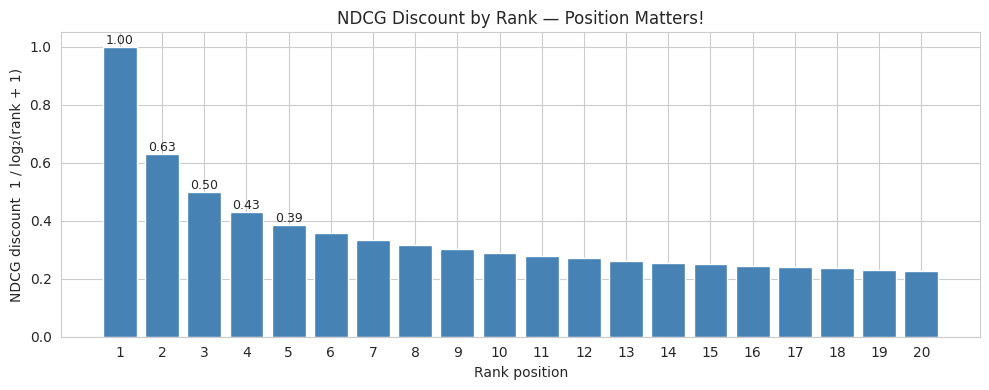

Rank 1 → 1.00  |  Rank 2 → 0.63  |  Rank 5 → 0.43  |  Rank 10 → 0.29


In [30]:
# ── Visualize: how the discount works ─────────────────────────────────────
ranks = np.arange(1, 21)
discounts = 1 / np.log2(ranks + 1)

plt.figure(figsize=(10, 4))
plt.bar(ranks, discounts, color='steelblue', edgecolor='white')
plt.xlabel("Rank position")
plt.ylabel("NDCG discount  1 / log₂(rank + 1)")
plt.title("NDCG Discount by Rank — Position Matters!")
plt.xticks(ranks)
for r, d in zip(ranks[:5], discounts[:5]):
    plt.text(r, d + 0.01, f"{d:.2f}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()
print("Rank 1 → 1.00  |  Rank 2 → 0.63  |  Rank 5 → 0.43  |  Rank 10 → 0.29")

### 4.3 Mean Reciprocal Rank (MRR)

Where did the positive item land — across the entire list, not just top K?

MRR computes the reciprocal of the rank of the positive item. If it lands at position 1, the score is 1.0. Position 2 gives 0.5. Position 10 gives 0.1. Averaged across users, it tells you how high up the positive typically appears.

MRR has no K cutoff — it considers the full ranked list.

In [31]:
def mrr_score(ranked_list, pos_item):
    if pos_item not in ranked_list:
        return 0.0
    rank = ranked_list.index(pos_item) + 1  # 1-indexed
    return 1.0 / rank

---
## Section 5: Bayesian Personalized Ranking (BPR)

So far we have a way to evaluate a ranked list. But we haven't trained anything yet — we have no model that produces scores.

BPR is a loss function designed specifically for ranking. Instead of asking "how wrong is this score?", it asks "did we rank this positive item above this negative item?"

For each training step, BPR looks at a **triplet**: (user, positive item, negative item). The positive item is something the user interacted with. The negative item is something they didn't. The model is penalized if it scores the negative higher than the positive — and rewarded if it gets the order right.

$$\mathcal{L}_{BPR} = -\sum_{(u, i, j) \in D} \ln \sigma(\hat{x}_{ui} - \hat{x}_{uj})$$

Where $i$ is the positive item, $j$ is the negative item, and $\hat{x}$ is the model's score. The model only needs to get the direction right — not the absolute values.

### 5.1 From Records to Triplets

BPR doesn't train on individual interaction records. It trains on comparisons. Here is how raw interaction data becomes training triplets:

In [32]:
def build_triplets(df, n_negatives=1):
    """
    Convert interaction records into BPR training triplets.
    For each (user, positive item), sample n_negatives negative items.
    Returns a list of (user_id, positive_item_id, negative_item_id) tuples.
    """
    all_items = set(df['movieId'].unique())
    triplets = []

    for user_id, user_df in df.groupby('userId'):
        pos_items = set(user_df['movieId'].values)
        neg_items = list(all_items - pos_items)

        for pos_item in pos_items:
            negs = np.random.choice(neg_items, size=n_negatives, replace=False)
            for neg_item in negs:
                triplets.append((user_id, pos_item, neg_item))

    return triplets

triplets = build_triplets(train)
print(f"Total triplets: {len(triplets):,}")
print(f"\nExample triplets (user, positive item, negative item):")
for t in triplets[:5]:
    print(f"  User {t[0]:>4} | pos: {t[1]:>6} | neg: {t[2]:>6}")

Total triplets: 80,896

Example triplets (user, positive item, negative item):
  User    1 | pos:   2048 | neg:   1891
  User    1 | pos:      1 | neg:   3697
  User    1 | pos:   1025 | neg:  93766
  User    1 | pos:      3 | neg:   4147
  User    1 | pos:   1024 | neg:   2788


### 5.2 Training with BPR

In practice, building and iterating over triplets manually is slow. Libraries like `implicit` handle triplet sampling internally — you give it the interaction matrix and it constructs triplets on the fly during training.

The logic is identical to what we showed above. The difference is efficiency.

> ⚠️ One naming quirk in `implicit`: what the library calls `item_factors` are actually the user embeddings, and `user_factors` are the item embeddings. This is counter-intuitive — keep it in mind when extracting scores.

In [ ]:
from scipy.sparse import csr_matrix
import implicit

# Build user and item maps
user_ids  = train['userId'].unique()
item_ids  = train['movieId'].unique()
user_map  = {u: i for i, u in enumerate(user_ids)}
item_map  = {m: i for i, m in enumerate(item_ids)}

# Build sparse interaction matrix (items × users, as implicit expects)
rows = [item_map[m] for m in train['movieId']]
cols = [user_map[u] for u in train['userId']]
data = np.ones(len(train))
interaction_matrix = csr_matrix((data, (rows, cols)),
                                 shape=(len(item_ids), len(user_ids)))

# Train BPR
bpr_model = implicit.bpr.BayesianPersonalizedRanking(
    factors=64,
    iterations=100,
    learning_rate=0.01,
    regularization=0.01,
    random_state=42
)
bpr_model.fit(interaction_matrix)
print("✅ BPR model trained")

In [ ]:
def get_bpr_scores(user_id, candidates):
    """
    Score a list of candidate items for a user using BPR.
    Returns a dict {movie_id: score}.
    """
    if user_id not in user_map:
        return {}

    u_idx      = user_map[user_id]
    user_embed = bpr_model.item_factors[u_idx]  # note: implicit's naming is flipped

    scores = {}
    for movie_id in candidates:
        if movie_id in item_map:
            i_idx = item_map[movie_id]
            scores[movie_id] = float(bpr_model.user_factors[i_idx] @ user_embed)
    return scores

---
## Section 6: Pointwise vs. Pairwise — Head to Head

We now have everything we need to compare the two approaches on the same data.

Remember the distinction from section 2: pointwise optimizes for score accuracy, pairwise optimizes for order. We can now see what that means in practice by measuring both on two sets of metrics:

- **Rating metrics**: RMSE, MAE — how accurate are the absolute scores?
- **Ranking metrics**: HR@10, NDCG@10, MRR — how good is the ranked list?

A pointwise model should do well on RMSE and MAE. A pairwise model should do well on HR, NDCG, and MRR. The question is: how much does each sacrifice on the other's turf?

### 6.1 Pointwise: Matrix Factorization with MSE

We train a simple matrix factorization model using MSE loss — predicting the interaction value for each (user, item) pair independently.

In [39]:
def train_mf_sgd(train_df, n_factors=64, lr=0.01, reg=0.01, n_epochs=20):
    """
    Train matrix factorization with SGD and MSE loss.

    For each interaction:
      1. Predict rating as dot product of user and item embeddings
      2. Compute error against actual rating
      3. Update embeddings to minimize MSE
    """
    user_ids = train_df['userId'].unique()
    item_ids = train_df['movieId'].unique()
    user_idx = {u: i for i, u in enumerate(user_ids)}
    item_idx = {m: i for i, m in enumerate(item_ids)}

    # Initialize embeddings randomly
    U = np.random.normal(0, 0.1, (len(user_ids), n_factors))
    V = np.random.normal(0, 0.1, (len(item_ids), n_factors))

    interactions = train_df[['userId', 'movieId', 'rating']].values

    for epoch in range(n_epochs):
        np.random.shuffle(interactions)
        total_loss = 0

        for user_id, movie_id, rating in interactions:
            u = user_idx[user_id]
            i = item_idx[movie_id]

            # Predict and compute error
            pred  = U[u] @ V[i]
            error = rating - pred
            total_loss += error ** 2

            # Update embeddings (MSE gradient + L2 regularization)
            U[u] += lr * (error * V[i] - reg * U[u])
            V[i] += lr * (error * U[u] - reg * V[i])

        rmse = np.sqrt(total_loss / len(interactions))
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:>3} / {n_epochs} — RMSE: {rmse:.4f}")

    return U, V, user_idx, item_idx

U, V, user_idx, item_idx = train_mf_sgd(train)
print("✅ Pointwise model trained")

Epoch   5 / 20 — RMSE: 0.9672
Epoch  10 / 20 — RMSE: 0.6424
Epoch  15 / 20 — RMSE: 0.4806
Epoch  20 / 20 — RMSE: 0.3794
✅ Pointwise model trained


In [43]:
def get_pointwise_scores(user_id, candidates):
    if user_id not in user_idx:
        return {}
    u = U[user_idx[user_id]]
    scores = {}
    for movie_id in candidates:
        if movie_id in item_idx:
            scores[movie_id] = float(u @ V[item_idx[movie_id]])
    return scores

# Rating metrics on test set
actuals, pointwise_preds = [], []
for _, row in test.iterrows():
    if row['userId'] in user_idx and row['movieId'] in item_idx:
        pred = U[user_idx[row['userId']]] @ V[item_idx[row['movieId']]]
        pointwise_preds.append(pred)
        actuals.append(row['rating'])

rmse_pw = np.sqrt(np.mean((np.array(actuals) - np.array(pointwise_preds))**2))
mae_pw  = np.mean(np.abs(np.array(actuals) - np.array(pointwise_preds)))
print(f"Pointwise — RMSE: {rmse_pw:.4f} | MAE: {mae_pw:.4f}")

Pointwise — RMSE: 1.0342 | MAE: 0.8012


In [44]:
K = 10
metrics = {
    'pointwise': {'hr': [], 'ndcg': [], 'mrr': []},
    'bpr':       {'hr': [], 'ndcg': [], 'mrr': []}
}

eval_users = [u for u in train['userId'].unique()
              if len(test[test['userId'] == u]) > 0]

for user_id in eval_users:
    pos_item, candidates = build_eval_candidates(user_id)
    if pos_item is None:
        continue

    for model_name, score_fn in [
        ('pointwise', lambda c: get_pointwise_scores(user_id, c)),
        ('bpr',       lambda c: get_bpr_scores(user_id, c))
    ]:
        scores = score_fn(candidates)
        if not scores:
            continue
        ranked = sorted(scores, key=scores.get, reverse=True)
        metrics[model_name]['hr'].append(hit_rate_at_k(ranked, pos_item, K))
        metrics[model_name]['ndcg'].append(ndcg_at_k(ranked, pos_item, K))
        metrics[model_name]['mrr'].append(mrr_score(ranked, pos_item))

In [45]:
# BPR rating metrics
bpr_preds = []
actuals_bpr = []
for _, row in test.iterrows():
    if row['userId'] in user_map and row['movieId'] in item_map:
        u_idx = user_map[row['userId']]
        i_idx = item_map[row['movieId']]
        pred = float(bpr_model.user_factors[i_idx] @ bpr_model.item_factors[u_idx])
        bpr_preds.append(pred)
        actuals_bpr.append(row['rating'])

rmse_bpr = np.sqrt(np.mean((np.array(actuals_bpr) - np.array(bpr_preds))**2))
mae_bpr  = np.mean(np.abs(np.array(actuals_bpr) - np.array(bpr_preds)))

print(f"{'Metric':<12} {'Pointwise':>12} {'BPR (Pairwise)':>16}")
print("-" * 42)
print(f"{'RMSE':<12} {rmse_pw:>12.4f} {rmse_bpr:>16.4f}")
print(f"{'MAE':<12} {mae_pw:>12.4f} {mae_bpr:>16.4f}")
print(f"{'HR@10':<12} {np.mean(metrics['pointwise']['hr']):>12.4f} {np.mean(metrics['bpr']['hr']):>16.4f}")
print(f"{'NDCG@10':<12} {np.mean(metrics['pointwise']['ndcg']):>12.4f} {np.mean(metrics['bpr']['ndcg']):>16.4f}")
print(f"{'MRR':<12} {np.mean(metrics['pointwise']['mrr']):>12.4f} {np.mean(metrics['bpr']['mrr']):>16.4f}")

Metric          Pointwise   BPR (Pairwise)
------------------------------------------
RMSE               1.0342           2.4557
MAE                0.8012           2.1248
HR@10              0.4639           0.7222
NDCG@10            0.2674           0.4781
MRR                0.2279           0.4128


### What do the results tell us?

Pointwise optimizes for RMSE and MAE — and that shows in the numbers. BPR never sees absolute scores during training, so it has no reason to do well on those metrics.

On ranking metrics — HR, NDCG, MRR — BPR typically does better because it optimizes directly for order. But this is not guaranteed, and the gap depends on the data.

The takeaway is not that one approach is better. It is that **each model performs best on what it was trained to optimize**. Choosing between them is a product decision: what does your system actually need to be good at?

---
## Summary

In this notebook we built a ranking pipeline from scratch — evaluation protocol, metrics, and two models with different training objectives.

| | Pointwise (MF) | Pairwise (BPR) |
|---|---|---|
| **Optimizes** | Score accuracy (MSE) | Ranking order (BPR loss) |
| **Output** | Predicted rating (interpretable) | Score (relative order only) |
| **RMSE / MAE** | ✅ Good | ❌ Not meaningful |
| **HR@K, NDCG@K, MRR** | Okay | ✅ Better |
| **Cold start** | ❌ No interactions = no prediction | ❌ Same problem |

Neither approach is wrong — they optimize for different things, and the metrics reflect that. The choice depends on what your system needs to be good at.

**The pipeline we built:**
1. Define the task: produce a ranked list, not a predicted rating
2. Set up the evaluation protocol: 1 positive + N negatives per user
3. Define ranking metrics: HR@K, NDCG@K, MRR
4. Train a pointwise model (MF with MSE) and a pairwise model (BPR)
5. Compare on both rating and ranking metrics — each wins on what it was trained for

**➡️ In Notebook 3** we look at where the signal comes from — item-item and user-user collaborative filtering.